# Case IV

This notebook reproduces the Case IV plots seen in Sections 4.4 and B.2 of the paper.

The notebook contains:

1. An early-stopping sweep across $ES \in \{500, 1000, 2000, 3000\}$ for the fixed 2D architecture used in the main Case IV comparison.
2. Width-based comparisons over $W_D = W_G \in \{2, 4, 8, 16\}$.
3. Diffusion and growth function comparisons in density space, both across widths at fixed $ES$ and across $ES$ at fixed $W_D = W_G$.

*It produces plots for Fig. 10 and Fig. A5-A6 in the paper.*


In [1]:
import os
import sys
from contextlib import contextmanager
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.legend import Legend

PROJECT_ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "Training").is_dir()
)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Training.JN.notebook_helpers.notebook_data import (
    build_catalog,
    build_true_diffusion_callable,
    build_true_growth_callable,
    load_data_object,
)
from Training.JN.notebook_helpers.notebook_config import (
    BCbool,
    BNdataLossFuncLabel,
    D_one_param_bool,
    binn_lr,
    binn_model_num,
    binn_rel_save_thresh,
    binn_rel_update_thresh,
    binnDevice,
    binnGenerateIndicesLabel,
    binnVF,
)
from Training.JN.notebook_helpers.notebook_models import (
    active_constraint_settings,
    build_model_catalog,
    build_model_path,
    filter_model_catalog,
    load_requested_models,
    summarize_requested_models,
)
from Training.JN.notebook_helpers.notebook_setup import bootstrap_notebook, register_notebook_pickle_globals

paths = bootstrap_notebook(PROJECT_ROOT)
JN_ROOT = paths.notebook_root

register_notebook_pickle_globals()

from paper_helpers import (
    scale_function_by_percent_error,
    plot_diff_mse_lst_2d,
    plot_eval_D_multi_gray_2d,
    plot_eval_G_multi_gray_2d,
    plot_final_loss_lst,
    plot_grow_mse_lst_2d,
    plot_initial_condition_2d,
    plot_total_run_times_lst,
    true_diffusion_expression,
    true_growth_expression,
)


## 1. Load the Case IV data

We first recover the noisy 2D reaction-diffusion dataset used throughout Case IV, then define the fixed data configuration and the small growth-family helper used to load matching data objects from disk. As in the other case notebooks, this section verifies the data objects before any model analysis begins. The spatial and temporal grids follow [Lagergren et al. (2020)](https://doi.org/10.1371/journal.pcbi.1008462)

MSE between u and u_clean: 0.6512693806378989
ABS between u and u_clean [cells]: 21.13294784721393
ABS (%) between u and u_clean (on |u_clean| >= 1.000e-06): 5.00676329547012


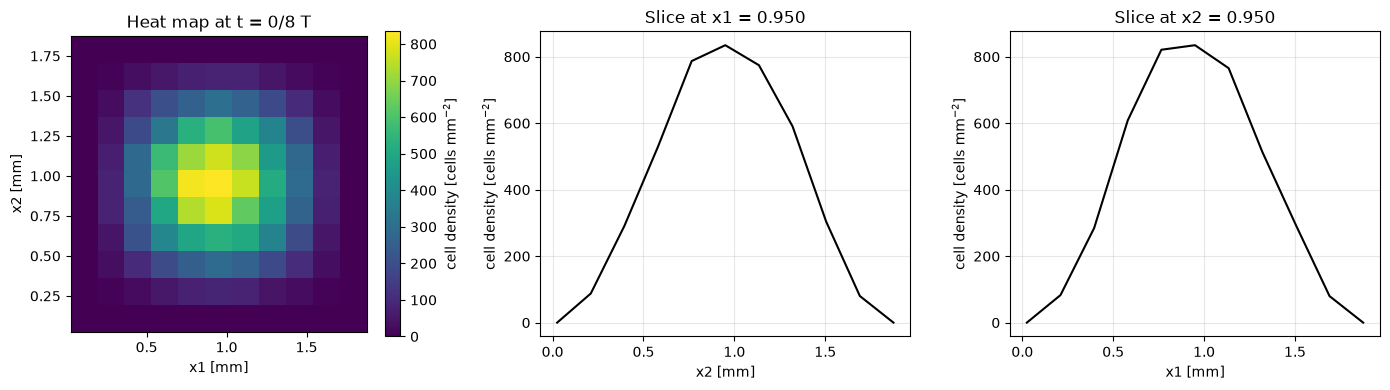

In [2]:
DATA_ROOT = paths.data_root

CASE4_GROWTH_LABELS = ["linear"]
CASE4_BASE_DATA_CONFIG = {
    "dataX1num": 11,
    "dataX2num": 11,
    "dataTnum": 9,
    "dataK": 1,
    "dataICLabel": "cos",
    "dataDiffLabel": "const",
    "dataGrowLabel": "linear",
    "dataGamma": 1,
    "dataNoisePercent": 5,
    "dataNoiseSeed": 0,
}
CASE4_DATA_CONFIG = CASE4_BASE_DATA_CONFIG.copy()
REALISTIC_CARRYING_CAPACITY = 1700  # cells/mm^2

def build_case4_data_config(grow_label):
    return CASE4_BASE_DATA_CONFIG | {"dataGrowLabel": grow_label}


data_df = build_catalog(DATA_ROOT, target_filename="data_obj.npy")
data_obj_by_growth = {
    grow_label: load_data_object(
        build_case4_data_config(grow_label),
        DATA_ROOT,
        data_df=data_df,
    )[0]
    for grow_label in CASE4_GROWTH_LABELS
}
fixed_grow_label = CASE4_DATA_CONFIG["dataGrowLabel"]
data_obj = data_obj_by_growth[fixed_grow_label]

plot_initial_condition_2d(data_obj)


## 2. Build the Case IV model catalogue & form helper functions for model loading and plotting


### 2.1. Catalogue trained model

Next we catalogue all saved 2D BINN checkpoints under `Training/binn`, filter them to the fixed Case IV assumptions, and preview the subsets that support the early-stopping and width sweeps below.

The varying dimensions in this notebook are `binnES`, `binnDsize`, `binnGsize`, and `binnTVsplitSeed` for the width sweep, plus `binnUsize` for the fixed-width ES sweep; everything else is held fixed for Case IV.


In [3]:
BINN_ROOT = paths.binn_root
binn_df = build_model_catalog(BINN_ROOT)

CASE4_NUM_PDE_SAMPLES = 100
ALL_CONSTRAINTS = True
CONSTRAINT_TUPLE = (True, True, True, True)
CONSTRAINT_WEIGHTS = {
    "D_bound_weight": 0,
    "D_mono_weight": 1e1,
    "G_bound_weight": 0,
    "G_mono_weight": 1e1,
}
CONSTRAINT_BOUNDS = {
    "D_bound": (0, 0.1),
    "G_bound": (-0.02 / (1 / 24), 0.1 / (1 / 24)),
}

ES_VALUES = [500, 1000, 2000, 3000]
TV_SPLIT_SEEDS = [0, 1, 2]
WIDTH_VALUES = [2, 4, 8, 16]
SELECTED_ES = ES_VALUES[-1]
SELECTED_WIDTH_FOR_PROFILES = WIDTH_VALUES[-1]
FIXED_U_WIDTH = 64
FIXED_D_WIDTH = 4
FIXED_G_WIDTH = 4
diff_label = CASE4_BASE_DATA_CONFIG["dataDiffLabel"]
CASE4_BATCH_SIZE = CASE4_BASE_DATA_CONFIG["dataX1num"] * CASE4_BASE_DATA_CONFIG["dataX2num"]

CASE4_SHARED_MODEL_FILTERS = {
        "binnVF": binnVF,
        "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
        "binnUsize": FIXED_U_WIDTH,
        "DoneParamBool": D_one_param_bool,
        "binnDevice": binnDevice,
        "allConstraints": ALL_CONSTRAINTS,
        "BCbool": BCbool,
        "numPDEsamples": CASE4_NUM_PDE_SAMPLES,
        "binnLR": binn_lr,
        "binnBatchSize": CASE4_BATCH_SIZE,
        "binnRelUpdateThresh": binn_rel_update_thresh,
        "binnRelSaveThresh": binn_rel_save_thresh,
        "BNdataLossFuncLabel": BNdataLossFuncLabel,
}
if ALL_CONSTRAINTS:
    CASE4_SHARED_MODEL_FILTERS |= active_constraint_settings(
        CONSTRAINT_TUPLE,
        CONSTRAINT_WEIGHTS,
        CONSTRAINT_BOUNDS,
    )


def build_case4_model_filters(grow_label, **overrides):
    return build_case4_data_config(grow_label) | CASE4_SHARED_MODEL_FILTERS | overrides


CASE4_FIXED_FILTERS = build_case4_model_filters(
    fixed_grow_label,
    binnGsize=FIXED_G_WIDTH,
)

case4_catalog_by_growth = {}
for grow_label in CASE4_GROWTH_LABELS:
    catalog = filter_model_catalog(
        binn_df,
        build_case4_model_filters(grow_label),
        empty_message=f"No 2D BINN models were found for growth label {grow_label!r}.",
    )
    case4_catalog_by_growth[grow_label] = catalog.sort_values(
        ["binnES", "binnDsize", "binnGsize", "binnTVsplitSeed"]
    ).reset_index(drop=True)

CATALOG_COLUMNS = ["dataGrowLabel", "binnES", "binnDsize", "binnGsize", "binnTVsplitSeed", "full_path"]
pd.concat(case4_catalog_by_growth.values(), ignore_index=True)[CATALOG_COLUMNS]

case4_fixed_catalog = filter_model_catalog(
    binn_df,
    CASE4_FIXED_FILTERS,
    empty_message="No 2D BINN models were found for the fixed-width ES comparison configuration.",
)
case4_fixed_catalog = case4_fixed_catalog.sort_values(
    ["binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"]
).reset_index(drop=True)


### 2.2. Helper functions for loading trained models


In [4]:
def build_model_path_case4(grow_label, width, split_seed, binn_es):
    return build_model_path(
        BINN_ROOT,
        build_case4_model_filters(grow_label),
        {
            "binnTVsplitSeed": split_seed,
            "binnUsize": FIXED_U_WIDTH,
            "binnDsize": width,
            "binnGsize": width,
            "binnES": binn_es,
        },
        model_df=case4_catalog_by_growth[grow_label],
        model_label=binn_model_num,
    )


def build_requested_paths(grow_label, es_values, widths, split_seeds):
    return [
        {
            "binnES": binn_es,
            "width": width,
            "binnTVsplitSeed": split_seed,
            "path": build_model_path_case4(grow_label, width, split_seed, binn_es),
        }
        for binn_es in es_values
        for width in widths
        for split_seed in split_seeds
    ]


def summarize_model_availability(grow_label, es_values, widths, split_seeds):
    print(f"Growth = {grow_label}")
    return summarize_requested_models(
        build_requested_paths(grow_label, es_values, widths, split_seeds),
        label_keys=["binnES", "width", "binnTVsplitSeed"],
    )


def load_case4_models(grow_labels, es_values, widths, split_seeds):
    models_by_growth = {}
    for grow_label in grow_labels:
        models_by_growth[grow_label] = load_requested_models(
            build_requested_paths(grow_label, es_values, widths, split_seeds),
            device=binnDevice,
            group_keys=("binnES", "width", "binnTVsplitSeed"),
        )
    return models_by_growth


def build_fixed_model_path(d_width, u_width, split_seed, binn_es):
    return build_model_path(
        BINN_ROOT,
        CASE4_FIXED_FILTERS,
        {
            "binnTVsplitSeed": split_seed,
            "binnUsize": u_width,
            "binnDsize": d_width,
            "binnGsize": FIXED_G_WIDTH,
            "binnES": binn_es,
        },
        model_df=case4_fixed_catalog,
        model_label=binn_model_num,
    )


def build_fixed_requested_paths(es_values, d_sizes, u_sizes, split_seeds):
    return [
        {
            "binnES": binn_es,
            "binnDsize": d_width,
            "binnUsize": u_width,
            "binnTVsplitSeed": split_seed,
            "path": build_fixed_model_path(d_width, u_width, split_seed, binn_es),
        }
        for binn_es in es_values
        for d_width in d_sizes
        for u_width in u_sizes
        for split_seed in split_seeds
    ]


def summarize_fixed_model_availability(es_values, d_sizes, u_sizes, split_seeds):
    return summarize_requested_models(
        build_fixed_requested_paths(es_values, d_sizes, u_sizes, split_seeds),
        label_keys=["binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"],
    )


def load_case4_models_by_es(es_values, d_sizes, u_sizes, split_seeds):
    return load_requested_models(
        build_fixed_requested_paths(es_values, d_sizes, u_sizes, split_seeds),
        device=binnDevice,
        group_keys=("binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"),
    )


for grow_label in CASE4_GROWTH_LABELS:
    summarize_model_availability(
        grow_label,
        es_values=ES_VALUES,
        widths=WIDTH_VALUES,
        split_seeds=TV_SPLIT_SEEDS,
    )
binn_models_by_growth = load_case4_models(
    grow_labels=CASE4_GROWTH_LABELS,
    es_values=ES_VALUES,
    widths=WIDTH_VALUES,
    split_seeds=TV_SPLIT_SEEDS,
)

summarize_fixed_model_availability(
    es_values=ES_VALUES,
    d_sizes=[FIXED_D_WIDTH],
    u_sizes=[FIXED_U_WIDTH],
    split_seeds=TV_SPLIT_SEEDS,
)
binn_models_by_es = load_case4_models_by_es(
    es_values=ES_VALUES,
    d_sizes=[FIXED_D_WIDTH],
    u_sizes=[FIXED_U_WIDTH],
    split_seeds=TV_SPLIT_SEEDS,
)
fixed_width_models_by_es = {
    str(binn_es): binn_models_by_es[binn_es][FIXED_D_WIDTH][FIXED_U_WIDTH]
    for binn_es in ES_VALUES
}


Growth = linear
Requested model combinations: 48
Already trained model files found: 48
Missing model files: 0
Requested model combinations: 12
Already trained model files found: 12
Missing model files: 0


### 2.3 Shared plotting style

These settings are reused across the Case IV ES sweep, width comparisons, and 2D real-space function plots.


In [5]:
BLUE_COLORS = ["#0033A0", "#1E90FF", "#6699CC", "#A4C8E1", "#D6EAF8"]
D_COLORS = ["#8B2500", "#FF7F0E", "#FDB863", "#FDD9B5", "#FFF1E0"]
G_COLORS = ["#00441B", "#1A9850", "#66C2A4", "#B2E2E2", "#E5F5F9"]
linestyles = ["-"] * 5
MARKER_STYLES = ["o"] * 5
AXIS_FONTSIZES = {
    "xaxis": 18,
    "xtick_labels": 18,
    "yaxis": 18,
    "ytick_labels": 18,
}
LEGEND_SIZE = 18
WIDTH_AXIS_LABEL = r"$W_D=W_G$"
REFERENCE_MPE_LEVELS = [5, 10]
LOSS_BBOX = (0.68, 1.0)
PE_BBOX_OFFSET = (0.32, 0.0)


def plot_params_from_models(models_dict, colors):
    labels = [str(key) for key in models_dict.keys()]
    return {
        key: [colors[i], linestyles[i], MARKER_STYLES[i], labels[i]]
        for i, key in enumerate(models_dict.keys())
    }


def models_by_es_list(grow_label):
    return [binn_models_by_growth[grow_label][binn_es] for binn_es in ES_VALUES]


def models_by_width_for_es(grow_label, binn_es):
    return {str(width): binn_models_by_growth[grow_label][binn_es][width] for width in WIDTH_VALUES}


def make_output_dir(*parts):
    output_dir = JN_ROOT / "pngs" / "2D" / "case4"
    for part in parts:
        output_dir = output_dir / str(part)
    os.makedirs(output_dir, exist_ok=True)
    return output_dir


reference_diffusion_callable = build_true_diffusion_callable(diff_label)
reference_growth_callables = {
    grow_label: build_true_growth_callable(grow_label)
    for grow_label in CASE4_GROWTH_LABELS
}
ground_truth_diffusion = build_true_diffusion_callable(
    diff_label,
    theta_D=np.atleast_1d(data_obj.theta_D),
)
ground_truth_growth = build_true_growth_callable(
    fixed_grow_label,
    theta_G=np.atleast_1d(data_obj.theta_G),
)


def reference_mses(func, beta_list):
    return [scale_function_by_percent_error(func, beta=beta)[1] for beta in beta_list]

REFERENCE_DIFF_MSES = reference_mses(reference_diffusion_callable, REFERENCE_MPE_LEVELS)
REFERENCE_GROWTH_MSES = reference_mses(ground_truth_growth, REFERENCE_MPE_LEVELS)

name_intro = make_output_dir("figA5")
name_intro_fig10 = make_output_dir("fig10")
name_intro_figA6 = make_output_dir("figA6")



## 3. Sweep A: vary $ES$ for the fixed 2D architecture

This section reproduces the fixed-width early-stopping comparison. It first compares training performance across $ES$, then summarizes the final diffusion and growth MSE values, and finally overlays the learned diffusion and growth functions in real space.


All x-axis labels found (ordered): ['2', '4', '8', '16']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_final_loss.py:216: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(bool(grid), axis="y", which="both", linestyle="-", linewidth=0.5, alpha=grid_alpha)


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/2D/case4/figA5/plot_a_1.png


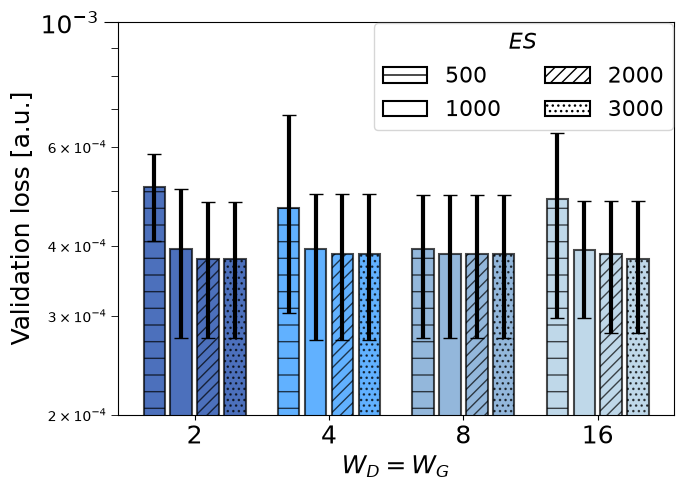

All x-axis labels found (ordered): ['500', '1000', '2000', '3000']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_final_loss.py:216: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(bool(grid), axis="y", which="both", linestyle="-", linewidth=0.5, alpha=grid_alpha)


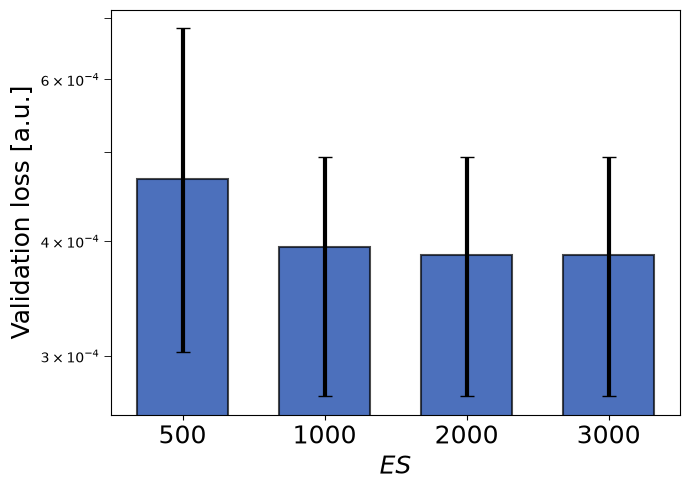

All x-axis labels found (ordered): ['500', '1000', '2000', '3000']


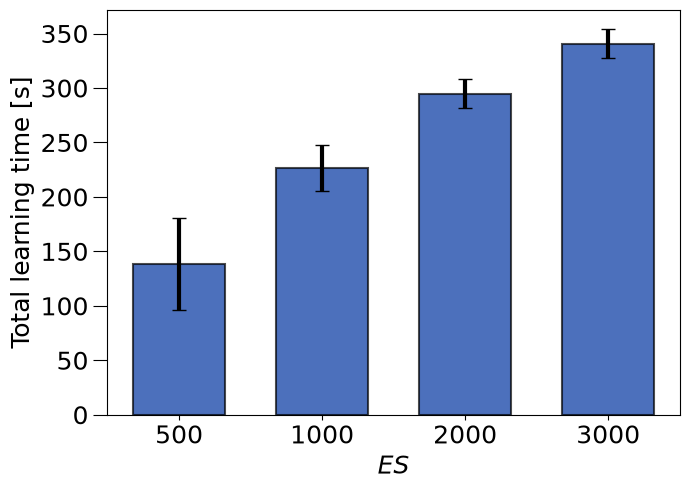

In [6]:
hatch_patterns = ("-", "", "///", "...")
models_for_plot = models_by_es_list(fixed_grow_label)
selected_es_models = binn_models_by_growth[fixed_grow_label][SELECTED_ES]
blue_plot_params = plot_params_from_models(
    selected_es_models,
    BLUE_COLORS[: len(WIDTH_VALUES)],
)
# Plot (a) in Fig A5
# =====================
plot_final_loss_lst(
    models_for_plot,
    plot_params=blue_plot_params,
    label_list=[str(binn_es) for binn_es in ES_VALUES],
    name=str(name_intro / "plot_a_1.png"),
    bbox_to_anchor=(0.44, 1.025),
    y_label="Validation loss [a.u.]",
    legend_size=16,
    legend_ncols=2,
    figsize=(7, 5),
    hatch_patterns=hatch_patterns,
    x_label=WIDTH_AXIS_LABEL,
    axis_fontsizes=AXIS_FONTSIZES,
    ylim=(2e-4, 1e-3),
    legend_title="$ES$",
    grid=False,
)


single_blue_palette = [BLUE_COLORS[0]] * len(ES_VALUES)
blue_plot_params_by_es = {
    str(binn_es): [single_blue_palette[i], "-", "o", str(binn_es)]
    for i, binn_es in enumerate(ES_VALUES)
}

# First plot in (a) in Fig 10
# ===========================
plot_final_loss_lst(
        models_dics_list=[fixed_width_models_by_es],
        plot_params=blue_plot_params_by_es,
        label_list=[rf"$W_u={FIXED_U_WIDTH}$"],
        name=None,
        bbox_to_anchor=(0.5, 1),
        y_label="Validation loss [a.u.]",
        legend_size=14,
        x_label="$ES$",
        figsize=(7, 5),
        legend_ncols=1,
        axis_fontsizes=AXIS_FONTSIZES,
        colors=single_blue_palette,
        legend_bool=False,
        grid=False,
    )

# Second plot in (a) in Fig 10
# ===========================
plot_total_run_times_lst(
        models_dics_list=[fixed_width_models_by_es],
        plot_params=blue_plot_params_by_es,
        label_list=[rf"$W_u={FIXED_U_WIDTH}$"],
        legend_pos=(1, 1),
        legend_fontsize=14,
        y_label="Total learning time [s]",
        x_label="$ES$",
        name=None,
        legend_ncols=1,
        y_scale="linear",
        axis_fontsizes=AXIS_FONTSIZES,
        figsize=(7, 5),
        colors=single_blue_palette,
        legend_bool=False,
    )


All x-axis labels found (ordered): ['500', '1000', '2000', '3000']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/2D/case4/figA6/fig_a.png


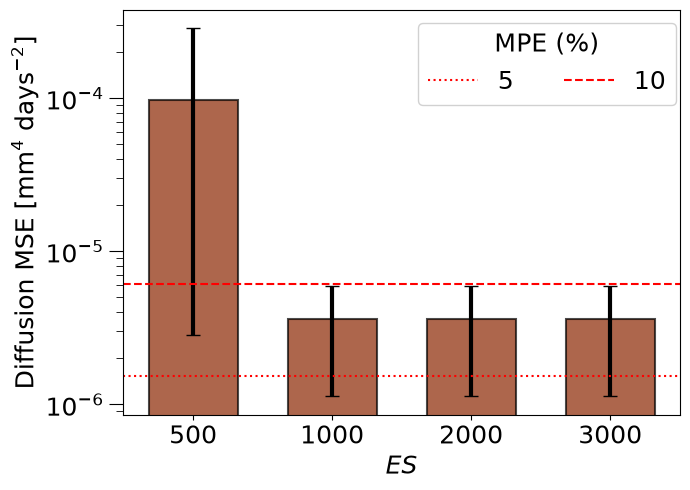

All x-axis labels found (ordered): ['500', '1000', '2000', '3000']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/2D/case4/figA6/fig_b.png


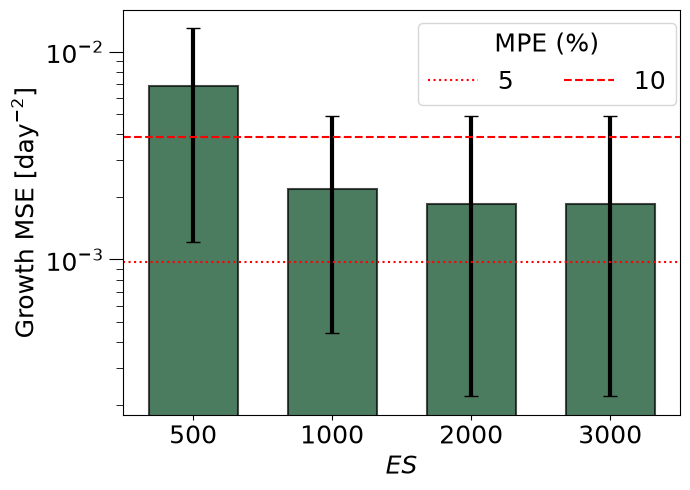

In [7]:
diffusion_plot_params = plot_params_from_models(
    selected_es_models,
    D_COLORS[: len(WIDTH_VALUES)],
)
growth_plot_params = plot_params_from_models(
    selected_es_models,
    G_COLORS[: len(WIDTH_VALUES)],
)


D_COLORS_ES = D_COLORS[: len(ES_VALUES)]
G_COLORS_ES = G_COLORS[: len(ES_VALUES)]
diffusion_plot_params_by_es = {
    str(binn_es): [D_COLORS_ES[i], linestyles[i], MARKER_STYLES[i], binn_es]
    for i, binn_es in enumerate(ES_VALUES)
}
growth_plot_params_by_es = {
    str(binn_es): [G_COLORS_ES[i], linestyles[i], MARKER_STYLES[i], binn_es]
    for i, binn_es in enumerate(ES_VALUES)
}

# Plot (a) in Fig A6 
# =====================
plot_diff_mse_lst_2d(
    [fixed_width_models_by_es],
    plot_params=diffusion_plot_params_by_es,
    label_list=[str(binn_es) for binn_es in ES_VALUES],
    name=os.path.join(name_intro_figA6, "fig_a.png"),
    figsize=(7, 5),
    bbox_to_anchor=(0.665, 1),
    legend_size=LEGEND_SIZE,
    colors=[D_COLORS[0]] * len(ES_VALUES),
    pe_bbox_to_anchor_offset=(0.35, 0),
    pe_legend_title="MPE (%)",
    pe_label_list=[str(beta) for beta in REFERENCE_MPE_LEVELS],
    pe_values=REFERENCE_DIFF_MSES,
    pe_linestyles=(":", "--", "-", "-."),
    pe_legend_ncols=4,
    x_label="$ES$",
    legend_bool=False,
    pe_legend_bool=True,
    axis_fontsizes=AXIS_FONTSIZES,
)

# Plot (b) in Fig A6 
# =====================
plot_grow_mse_lst_2d(
    [fixed_width_models_by_es],
    plot_params=growth_plot_params_by_es,
    label_list=[str(binn_es) for binn_es in ES_VALUES],
    name=os.path.join(name_intro_figA6, "fig_b.png"),
    figsize=(7, 5),
    bbox_to_anchor=(0.665, 1),
    legend_size=LEGEND_SIZE,
    colors=[G_COLORS[0]] * len(ES_VALUES),
    pe_bbox_to_anchor_offset=(0.35, 0),
    pe_label_list=[str(beta) for beta in REFERENCE_MPE_LEVELS],
    pe_values=REFERENCE_GROWTH_MSES,
    pe_linestyles=(":", "--", "-", "-."),
    pe_legend_ncols=4,
    y_label=r"Growth MSE [day$^{-2}$]",
    pe_legend_title="MPE (%)",
    x_label="$ES$",
    legend_bool=False,
    pe_legend_bool=True,
    axis_fontsizes=AXIS_FONTSIZES,
)


## 4. Sweep B configuration: vary $W_D = W_G$ at fixed ES then vary ES at fixed $W_D = W_G$  -- compare diffusion and growth functions

The final section revisits the same Case IV models in density space. We first compare widths at fixed $ES = 3000$, then complement that with a early-stopping comparison at fixed width.


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/2D/case4/figA5/plot_b_1.png


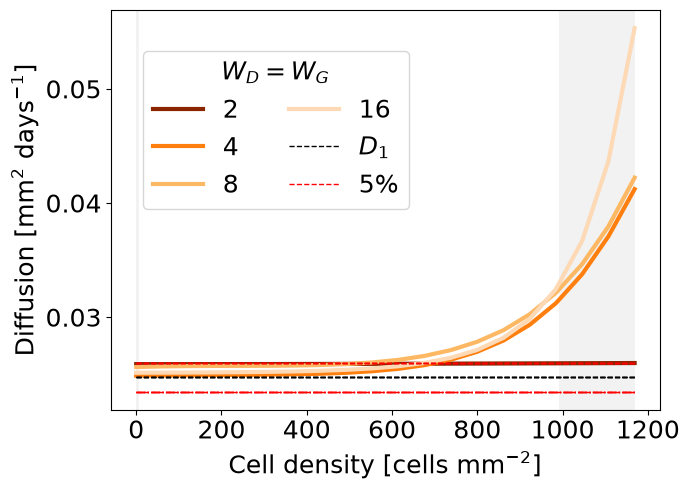

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/2D/case4/figA5/plot_b_2.png


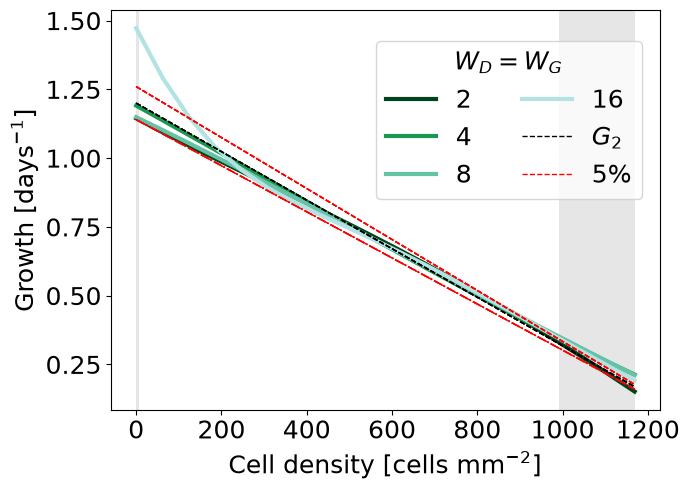

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/2D/case4/fig10/fig_c.png


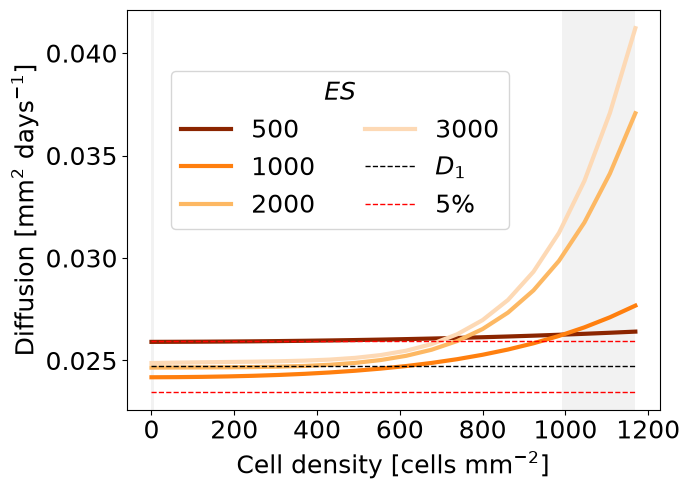

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/2D/case4/fig10/fig_d.png


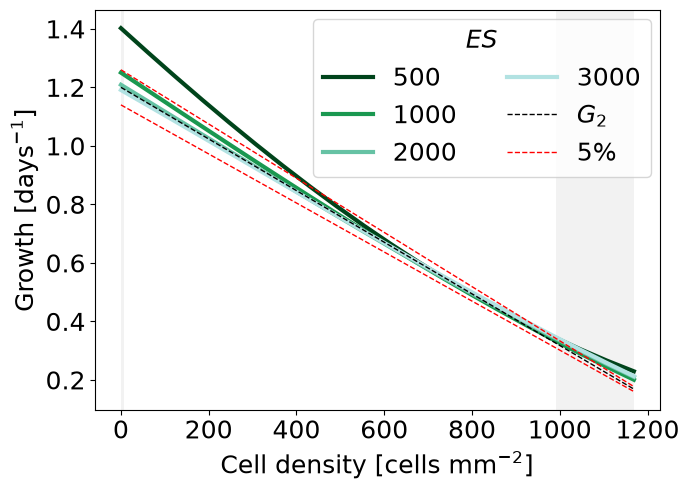

In [8]:
width_sweep_models = models_by_width_for_es(fixed_grow_label, SELECTED_ES)
width_labels = list(width_sweep_models.keys())
repeated_data_objects = [data_obj] * len(width_labels)
diffusion_symbolic_truths = [true_diffusion_expression(diff_label) for _ in width_labels]
growth_symbolic_truths = [true_growth_expression(fixed_grow_label) for _ in width_labels]



# First plot of (b) in Fig A5
# ===========================
plot_eval_D_multi_gray_2d(
    width_sweep_models,
    repeated_data_objects,
    diffusion_symbolic_truths,
    D_COLORS[: len(width_labels)],
    width_labels,
    Dnum=1,
    device="cpu",
    num_bins=50,
    K=REALISTIC_CARRYING_CAPACITY ,
    name=str(name_intro / "plot_b_1.png"),
    fill=False,
    legend_pos=(0.3, 0.7),
    legend_ncols=2,
    legend_fontsize=18,
    legend_title=WIDTH_AXIS_LABEL,
    linestyles=["-"] * len(width_labels),
    errs=[5, 5],
    axis_fontsizes=AXIS_FONTSIZES,
)

# Second plot of (b) in Fig A5
# =============================
plot_eval_G_multi_gray_2d(
    width_sweep_models,
    repeated_data_objects,
    growth_symbolic_truths,
    G_COLORS[: len(width_labels)],
    width_labels,
    Gnum=2,
    device="cpu",
    num_bins=50,
    K=REALISTIC_CARRYING_CAPACITY ,
    name=str(name_intro / "plot_b_2.png"),
    fill=False,
    legend_pos=(0.725, 0.725),
    legend_ncols=2,
    legend_fontsize=18,
    legend_title=WIDTH_AXIS_LABEL,
    linestyles=["-"] * len(width_labels),
    errs=[5, 5],
    axis_fontsizes=AXIS_FONTSIZES,
)

fixed_width_models_by_es_reduced = {
    str(binn_es): binn_models_by_es[binn_es][FIXED_D_WIDTH][FIXED_U_WIDTH]
    for binn_es in ES_VALUES
}
labels_fixed = [str(binn_es) for binn_es in ES_VALUES]


# First plot (b) in Fig 10
# ========================
plot_eval_D_multi_gray_2d(
    fixed_width_models_by_es_reduced,
    data_obj,
    [true_diffusion_expression(diff_label)],
    D_COLORS_ES,
    labels_fixed,
    Dnum=1,
    device="cpu",
    num_bins=50,
    K=REALISTIC_CARRYING_CAPACITY ,
    name=os.path.join(name_intro_fig10, "fig_c.png"),
    fill=False,
    legend_pos=(0.4, 0.65),
    linestyles=["-"] * len(ES_VALUES),
    legend_ncols=2,
    legend_fontsize=LEGEND_SIZE,
    legend_title="$ES$",
    errs=[5, 5],
    axis_fontsizes=AXIS_FONTSIZES,
)

# Second plot (b) in Fig 10
# ========================
plot_eval_G_multi_gray_2d(
    fixed_width_models_by_es_reduced,
    data_obj,
    [true_growth_expression(fixed_grow_label)],
    G_COLORS_ES,
    labels_fixed,
    Gnum=2,
    device="cpu",
    num_bins=50,
    K=REALISTIC_CARRYING_CAPACITY ,
    name=os.path.join(name_intro_fig10, "fig_d.png"),
    fill=False,
    legend_pos=(0.685, 0.78),
    linestyles=["-"] * len(ES_VALUES),
    legend_ncols=2,
    legend_fontsize=LEGEND_SIZE,
    legend_title="$ES$",
    errs=[5, 5],
    axis_fontsizes=AXIS_FONTSIZES,
)


## References

J. H. Lagergren et al. "Biologically-informed neural networks guide mechanistic modeling from sparse experimental data". In: *PLoS Comput Biol* 16.12 (2020), e1008462. DOI: [10.1371/journal.pcbi.1008462](https://doi.org/10.1371/journal.pcbi.1008462).
